In [1]:
import globals as gl

import os
import numpy as np
import sys

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa

import warnings
warnings.filterwarnings("ignore")

plt.close('all')
plt.style.use('default')


Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


 # **Cue representation**

## **Planning**

Text(0.5, 0.98, 'Planning, average distances across participants (N=5), hemisphere:L')

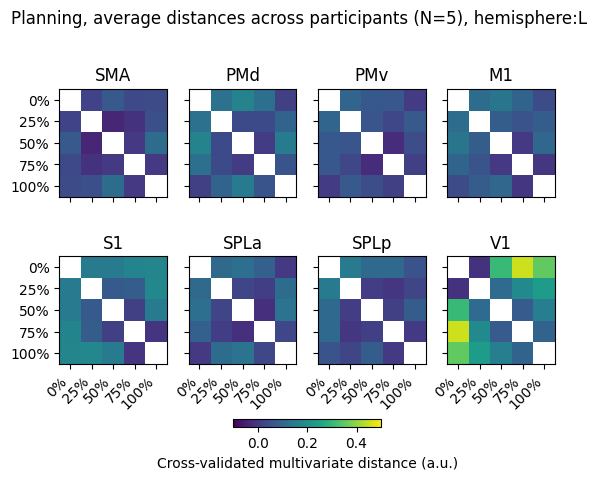

In [4]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Planning, average distances across participants (N={len(snS)}), hemisphere:{Hem}')

## **Execution**

TimeoutError: [Errno 60] Unable to open file (unable to open file: name = '/Volumes/diedrichsen_data$/data/SensoriMotorPrediction/smp2/rdm/subj102/glm12.L.SMA.hdf5', errno = 60, error message = 'Operation timed out', flags = 0, o_flags = 0)

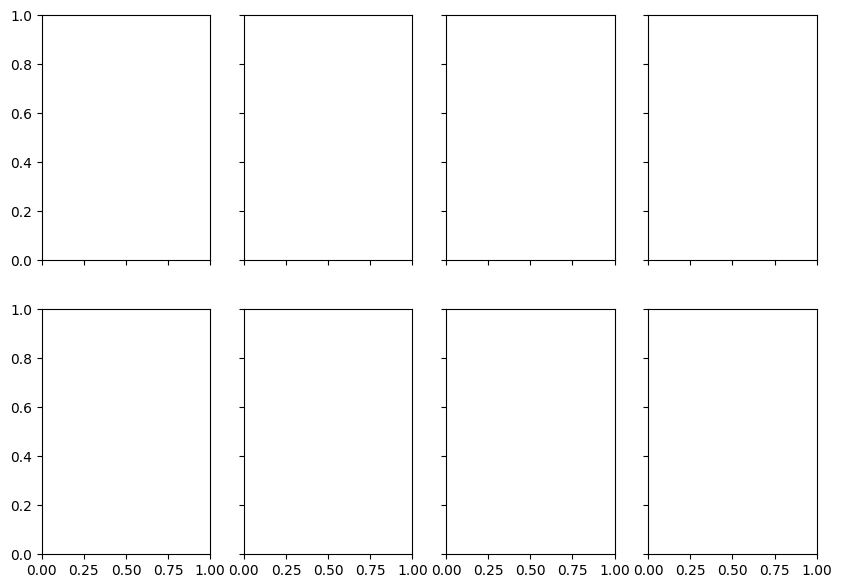

In [5]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1.5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Execution, average distances across participants (N={len(snS)}), hemisphere:{Hem}')


Fitting group cross model 0
Fitting group cross model 1
Fitting group cross model 2
Fitting group cross model 3
Fitting group cross model 4
Fitting group cross model 5
Fitting group cross model 6


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x12780ac20> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



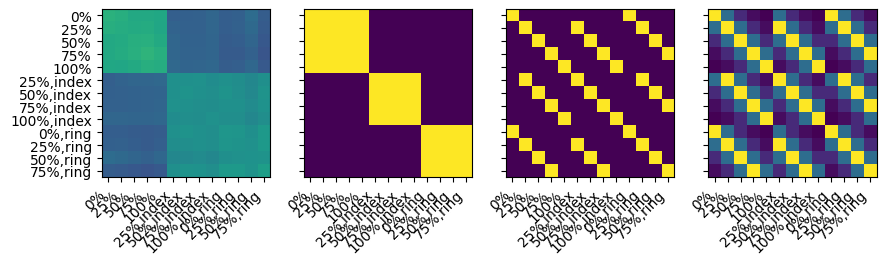

In [5]:
import PcmPy as pcm

snS = [102, 103, 104, 106]

experiment = 'smp2'
Hem = 'L'
glm = 12
roi = 'V1'

Z_stimFinger = np.zeros((13, 3))
Z_stimFinger[0:5, 0] = 1
Z_stimFinger[5:9, 1] = 1
Z_stimFinger[9:13, 2] = 1

Z_cue = np.zeros((13, 5))
Z_cue[[0,9], 0] = 1
Z_cue[[1,5,10], 1] = 1
Z_cue[[2,6,11], 2] = 1
Z_cue[[3,7,12], 3] = 1
Z_cue[[4,8], 4] = 1

# Define parameters
num_conditions = 13
num_cues = 5
alpha = 1  # Controls covariance falloff
sigma_sq = 1  # Variance of cues

# Compute similarity matrix
S = np.exp(-alpha * np.abs(np.arange(num_cues)[:, None] - np.arange(num_cues)[None, :]))

# Convert to covariance matrix
cov_matrix = sigma_sq * S

# Transform Z_cue to incorporate correlation structure
Z_cue_transformed = Z_cue @ np.linalg.cholesky(cov_matrix)

N=len(snS)
G_hat_betas = np.zeros((N,13,13))
Y = list()
for s, sn in enumerate(snS):

    reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')

    betas = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.beta.npy'))
    res = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.res.npy'))

    betas_prewhitened = betas / res

    cond_vec = reginfo.name.str.replace(" ", "").map(gl.regressor_mapping)
    part_vec = reginfo.run

    obs_des = {'cond_vec': cond_vec,
               'part_vec': part_vec}

    Y.append(pcm.dataset.Dataset(betas_prewhitened, obs_descriptors=obs_des))

    G_hat_betas[s],_ = pcm.est_G_crossval(Y[s].measurements, Y[s].obs_descriptors['cond_vec'], Y[s].obs_descriptors['part_vec'], X=pcm.matrix.indicator(Y[s].obs_descriptors['part_vec']))

vmin = G_hat_betas.min()
vmax = G_hat_betas.max()

fig, axs = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(10, 7))

axs[0].imshow(G_hat_betas.mean(axis=0),vmin=vmin,vmax=vmax)
axs[1].imshow(Z_stimFinger @ Z_stimFinger.T)
axs[2].imshow(Z_cue @ Z_cue.T)
axs[3].imshow(Z_cue_transformed @ Z_cue_transformed.T)

for ax in axs:
    ax.set_xticks(np.arange(G_hat_betas.shape[1]))
    ax.set_yticks(np.arange(G_hat_betas.shape[2]))
    ax.set_xticklabels(gl.regressor_mapping.keys(), rotation=45, ha='right')
    ax.set_yticklabels(gl.regressor_mapping.keys(),  ha='right')

M = []
M.append(pcm.FixedModel('null',np.eye(13)))
M.append(pcm.FixedModel('stimFinger', Z_stimFinger @ Z_stimFinger.T))
M.append(pcm.FixedModel('cue', Z_cue @ Z_cue.T))
M.append(pcm.FixedModel('cue_t', Z_cue_transformed @ Z_cue_transformed.T))
M.append(pcm.ComponentModel('stimFinger+cue',np.array([Z_stimFinger @ Z_stimFinger.T,Z_cue @ Z_cue.T])))
M.append(pcm.ComponentModel('stimFinger+cue_t',np.array([Z_stimFinger @ Z_stimFinger.T,Z_cue_transformed @ Z_cue_transformed.T])))
M.append(pcm.FreeModel('ceil',13)) # Noise ceiling model

T_cv, theta_cv = pcm.fit_model_group_crossval(Y,M, fit_scale=True, verbose=True, fixed_effect='block')
T_gr, theta_gr = pcm.fit_model_group(Y,M, fit_scale=True, verbose=True, fixed_effect='block')


<Axes: xlabel='model', ylabel='Log Bayes Factor'>

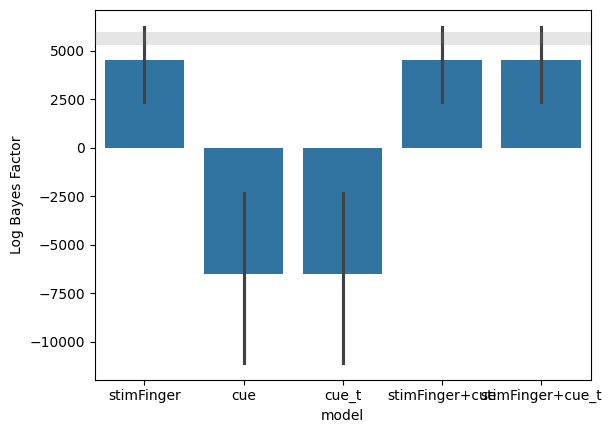

In [5]:
pcm.model_plot(T_cv.likelihood, null_model='null', upper_ceiling = T_gr.likelihood['ceil'], noise_ceiling= 'ceil')